# Experiment 2 — Echo-robustness (Theorem 2)

**What we are testing.** On the open web the *same fact* shows up on many pages — a press
release gets re-blogged dozens of times. A naive agent that trusts repetition will (a) **over-count**
the number when it adds things up, and (b) be **fooled into adopting a wrong value** just because the
wrong value was copied more times. Theorem 2 says our corroboration layer is immune to both:

> *Injecting any number of propagated copies of a value leaves the value's belief, and the
> aggregate it contributes to, unchanged. The aggregate only moves for **genuinely independent**
> corroboration.* (design doc `webaggr.pdf`, §3.4, Theorem 2)


**What this notebook does** (the §13.2 protocol):

1. Pick a **single-attribute SUM query**.
2. Run once normally and record the aggregate `A0`.
3. Inject `p ∈ {0, 5, 10, 25, 50}` propagated copies of one value (later timestamps, near-duplicate
   passages, same value) and re-aggregate to get `Ap`.
4. Compare against two provenance-blind baselines: a **count-based** sum and a **majority vote**.

**Pass criterion.** `|Ap − A0| / A0 < 0.01` for every `p` under our method, while the baseline
**drifts**. \
This experiment is **fully offline and synthetic** — it constructs `Source`/`Mention`
objects by hand and calls the real `webagg.corroboration.corroborate`. No API keys, no network.

## 0. Setup

Make `import webagg...` work no matter which folder Jupyter
was launched from. It walks up the directory tree until it finds the package
(`webagg/corroboration.py`) and puts that folder on the import path. Because this experiment is
synthetic, we import **only** the data types and the corroboration layer.

In [232]:
import sys, pathlib

def find_project_root(start=None):
    p = pathlib.Path(start or pathlib.Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "webagg" / "corroboration.py").exists():
            return cand
    raise RuntimeError(
        "Could not find the project root (a folder containing webagg/corroboration.py). "
        "Launch Jupyter from inside the repo, or set ROOT = pathlib.Path('/path/to/webagg')."
    )

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import hashlib, re
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt

from webagg.type_defs import Source, Mention
from webagg.corroboration import corroborate, reliability

FIGDIR = ROOT / "figures"; FIGDIR.mkdir(exist_ok=True)
print("project root :", ROOT)
print("imports OK    : corroborate, reliability, Source, Mention")

project root : D:\Projects\webagg
imports OK    : corroborate, reliability, Source, Mention


## 1. The building blocks

Two tiny helpers let us hand-build evidence. They mirror exactly what the real pipeline produces.

- **`make_source(domain, dt, text)`** : one *web page we read*. The fields that matter for
  Theorem 2 are `publish_time` (a copy must be **later** than its origin) and `main_text` (the
  wording the duplicate-detector compares).
- **`m_of(source, value)`** : one *claim pulled from a page* ("this page asserts `amount = value`").
  Its `passage` is the verbatim sentence the claim rests on, the text the provenance graph shingles
  to decide "is this a near-duplicate of another page?".
- **`parse_usd("$40M") → 40000000`** : so we can actually add the values up.

In [233]:
FIXED_TS = datetime(2025, 1, 1)  # deterministic extracted_at, keeps output stable

def make_source(domain: str, dt: datetime, text: str, salt: str = "") -> Source:
    """One fetched web page. 'dt' is both publish_time and fetch_time."""
    sid = hashlib.sha256(f"{domain}|{dt.isoformat()}|{text}|{salt}".encode()).hexdigest()[:16]
    return Source(
        source_id=sid, url=f"https://{domain}/article", domain=domain,
        fetch_time=dt, publish_time=dt, title=None, main_text=text,
        formulation_id="exp2",
    )

def m_of(src: Source, value: str, passage: str | None = None) -> Mention:
    """One extracted claim 'amount = value' from a page; passage defaults to the page text."""
    h = hashlib.sha256((value + src.source_id).encode()).hexdigest()[:8]
    return Mention(
        mention_id=f"{src.source_id}:amount:{h}", source_id=src.source_id,
        entity_surface="company", record_kind="funding_round", attribute="amount",
        value=value, passage=passage or src.main_text, extracted_at=FIXED_TS,
    )

def parse_usd(s: str) -> float:
    """'$40M' -> 40000000.0"""
    return float(re.sub(r"[^0-9.]", "", s)) * 1e6

# quick smoke check
_s = make_source("sec.gov", FIXED_TS, "demo")
print("reliability(sec.gov) =", reliability(_s), "| parse_usd('$40M') =", parse_usd("$40M"))

reliability(sec.gov) = 0.97 | parse_usd('$40M') = 40000000.0


## 2. The query and the ground truth

We use a **single-attribute SUM** query:

> *"Total Series A funding raised across the companies in a small portfolio."*

The single attribute is **`amount`**; the aggregate `f_Q` is **SUM** over the four companies. The
correct answer `A0` is just the sum of the four true amounts. This is the number Theorem 2 promises
will not move when we flood the web with copies.

Each company's amount is genuinely reported by **two independent sources with different wording**
(a news outlet and an SEC filing). Different wording → two separate components → `ν = 2` per
company. This is truth the web source *before* any adversarial copying.

In [234]:
GROUND_TRUTH = {"Acme": "$40M", "Globex": "$25M", "Initech": "$15M", "Hooli": "$20M"}
A0 = sum(parse_usd(v) for v in GROUND_TRUTH.values())

BASE = datetime(2025, 1, 1)
def genuine_sources(name: str, val: str):
    """Two genuinely independent witnesses, distinct wording -> two components."""
    texts = [
        f"{name} closed a {val} Series A round announced this week by the company.",
        f"In a regulatory filing, {name} reported raising {val} of Series A capital.",
    ]
    domains = [f"news-{name.lower()}.com", "sec.gov"]
    return [make_source(domains[i], BASE + timedelta(days=i), texts[i], salt=name)
            for i in range(2)]

RECORDS = {name: genuine_sources(name, val) for name, val in GROUND_TRUTH.items()}
print("Single attribute : amount   |   Aggregate f_Q : SUM over companies")
print("Ground-truth records:", GROUND_TRUTH)
print(f"True aggregate  A0 = ${A0/1e6:.0f}M")

Single attribute : amount   |   Aggregate f_Q : SUM over companies
Ground-truth records: {'Acme': '$40M', 'Globex': '$25M', 'Initech': '$15M', 'Hooli': '$20M'}
True aggregate  A0 = $100M


## 3. Two ways to compute the aggregate

**Our method — corroboration.** For each company we hand its
mentions to `corroborate(...)`. That builds the provenance graph, collapses copies into components,
runs the noisy-OR, and returns the **adopted value once**. We sum those adopted values. Copies
cannot inflate the sum because a value is contributed once per record regardless of how many pages
shout it.

**The baseline — count-based.** The naive agent from `webaggr.pdf` §3.1:
"if `$40M` appears on twelve pages, summing gives `$480M`." It adds the value once *per mention*, so
every copy adds the value again.

Both functions take `extra_acme_echoes` so we can inject copies of one company's value and watch what
each does.

In [235]:
def corroboration_sum(extra_acme_echoes: int = 0):
    """Our method: SUM of corroboration-adopted values (each distinct fact counted ONCE)."""
    total, detail = 0.0, {}
    for name, val in GROUND_TRUTH.items():
        srcs = list(RECORDS[name])
        if name == "Acme":
            srcs = srcs + echoes_of("Acme", val, extra_acme_echoes)
        lookup = {s.source_id: s for s in srcs}
        cv = corroborate({val: [m_of(s, val) for s in srcs]}, lookup)
        total += parse_usd(cv.value)               # contribute adopted value ONCE
        detail[name] = dict(nu=cv.nu, belief=round(cv.belief, 4),
                            comp_sizes=cv.component_sizes)
    return total, detail

def naive_count_sum(extra_acme_echoes: int = 0):
    """Baseline: SUM over EVERY appearance (no provenance, no dedup)."""
    total = 0.0
    for name, val in GROUND_TRUTH.items():
        srcs = list(RECORDS[name])
        if name == "Acme":
            srcs = srcs + echoes_of("Acme", val, extra_acme_echoes)
        total += sum(parse_usd(val) for _ in srcs)  # value re-added per page
    return total

## 4. The echo injection

A *propagated copy* is a page that lifted its wording from an earlier page. We manufacture `p` of
them for **Acme's `$40M`**:

- **later timestamps** than the original (a copy can't predate its source), and
- **near-duplicate passages** (identical text here) so `derivation_edge` fires.

Because each copy is a near-duplicate of an existing source and is later in time, it gets a
derivation edge into that source's component. The set of components — and therefore `ν` and the
noisy-OR belief — is **unchanged**. That is precisely the proof of Theorem 2, made concrete.

In [236]:
def echoes_of(name: str, val: str, p: int):
    """p near-duplicate copies of the FIRST genuine source, all timestamped later."""
    origin = RECORDS[name][0]
    return [make_source(f"echo{k}-{name.lower()}.example",
                        BASE + timedelta(days=10 + k),   # strictly after the origin
                        origin.main_text,                # identical wording -> near-dup edge
                        salt=f"{name}-echo-{k}")
            for k in range(p)]

# sanity: 5 echoes of Acme do not change Acme's independent-witness count
_, d0 = corroboration_sum(0)
_, d5 = corroboration_sum(5)
print("Acme @ p=0 :", d0["Acme"])
print("Acme @ p=5 :", d5["Acme"], "  <- nu and belief identical; only comp_sizes grow")

Acme @ p=0 : {'nu': 2, 'belief': 0.985, 'comp_sizes': [1, 1]}
Acme @ p=5 : {'nu': 2, 'belief': 0.985, 'comp_sizes': [6, 1]}   <- nu and belief identical; only comp_sizes grow


## 5. Run the sweep `p ∈ {0, 5, 10, 25, 50}`

For each injection level we record the corroboration aggregate `A_p`, the count-based baseline, and
Acme's `(ν, belief)` so we can see they never move.

In [237]:
P_VALUES = [0, 5, 10, 25, 50]
rows = []
for p in P_VALUES:
    A_corr, detail = corroboration_sum(p)
    A_base = naive_count_sum(p)
    rows.append({
        "p (echoes)": p,
        "A_p corroboration ($M)": A_corr / 1e6,
        "A_p count-based ($M)": A_base / 1e6,
        "rel. error |A_p-A0|/A0": abs(A_corr - A0) / A0,
        "nu(Acme)": detail["Acme"]["nu"],
        "belief(Acme)": detail["Acme"]["belief"],
    })
df = pd.DataFrame(rows)
df

,p (echoes),A_p corroboration ($M),A_p count-based ($M),rel. error |A_p-A0|/A0,nu(Acme),belief(Acme)
0,0,100.0,200.0,0.0,2,0.985
1,5,100.0,400.0,0.0,2,0.985
2,10,100.0,600.0,0.0,2,0.985
3,25,100.0,1200.0,0.0,2,0.985
4,50,100.0,2200.0,0.0,2,0.985


## 6. Pass criterion

Two things must hold:

1. **Our method is invariant:** `|A_p − A0| / A0 < 0.01` for every `p` (here it is exactly `0`).
2. **The baseline drifts monotonically:** each extra batch of copies strictly increases the
   count-based sum.

In [238]:
TOL = 0.01
ours_ok = bool((df["rel. error |A_p-A0|/A0"] < TOL).all())
base_vals = df["A_p count-based ($M)"].tolist()
base_monotone = all(b < a for b, a in zip(base_vals, base_vals[1:]))

print(f"[1] max relative error (ours) = {df['rel. error |A_p-A0|/A0'].max():.3e}  "
      f"(< {TOL}?)  -> {'PASS' if ours_ok else 'FAIL'}")
print(f"[2] baseline strictly rising  = {base_monotone}  "
      f"({base_vals[0]:.0f}M -> {base_vals[-1]:.0f}M)")
print("\nRESULT:", "PASS — Theorem 2 holds on this query"
      if (ours_ok and base_monotone) else "FAIL")

[1] max relative error (ours) = 0.000e+00  (< 0.01?)  -> PASS
[2] baseline strictly rising  = True  (200M -> 2200M)

RESULT: PASS — Theorem 2 holds on this query


## 7. The figure

Two lines, exactly as the protocol asks: corroboration flat on `A0`, the count-based baseline rising
with every injected copy.

saved D:\Projects\webagg\figures\exp2_echo_robustness.pdf


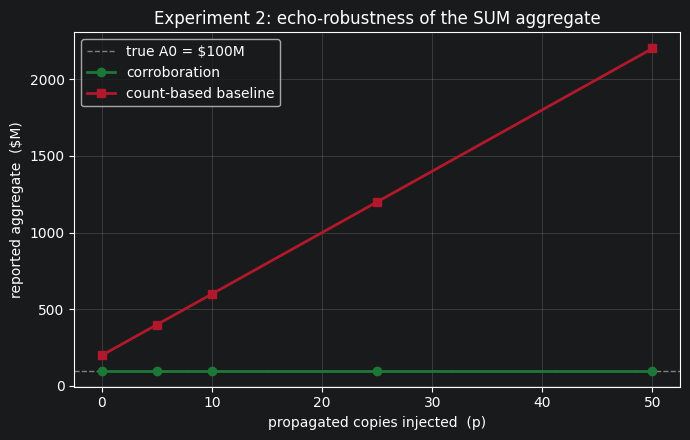

In [239]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(A0 / 1e6, ls="--", color="gray", lw=1, label=f"true A0 = ${A0/1e6:.0f}M")
ax.plot(df["p (echoes)"], df["A_p corroboration ($M)"], "o-", color="#1b7837", lw=2,
        label="corroboration")
ax.plot(df["p (echoes)"], df["A_p count-based ($M)"], "s-", color="#b2182b", lw=2,
        label="count-based baseline")
ax.set_xlabel("propagated copies injected  (p)")
ax.set_ylabel("reported aggregate  ($M)")
ax.set_title("Experiment 2: echo-robustness of the SUM aggregate")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGDIR / "exp2_echo_robustness.pdf")
print("saved", FIGDIR / "exp2_echo_robustness.pdf")
plt.show()

## 8. Is the flat line just the method ignoring everything?

No — and this is the second half of Theorem 2 (*strictly monotone in genuine independent
corroboration*). We compare two ways of adding sources to a single value whose lone origin is a
weak blog (`q = 0.50`):

- **Echoes** (near-duplicates, later timestamps): belief stays put — they're the *same witness*.
- **Genuine origins** (distinct wording, distinct domains): belief climbs toward 1 — each is a
  *new independent witness* adding a fresh `(1 − q)` factor to the noisy-OR.

If the system were simply discarding extra sources, the genuine curve would be flat too. It isn't.

,added sources,echoes: nu,echoes: belief,genuine: nu,genuine: belief
0,0,1,0.5,1,0.5000
1,1,1,0.5,2,0.7500
2,2,1,0.5,3,0.8750
3,3,1,0.5,4,0.9375
4,5,1,0.5,6,0.9844
5,8,1,0.5,9,0.9980
6,10,1,0.5,11,0.9995


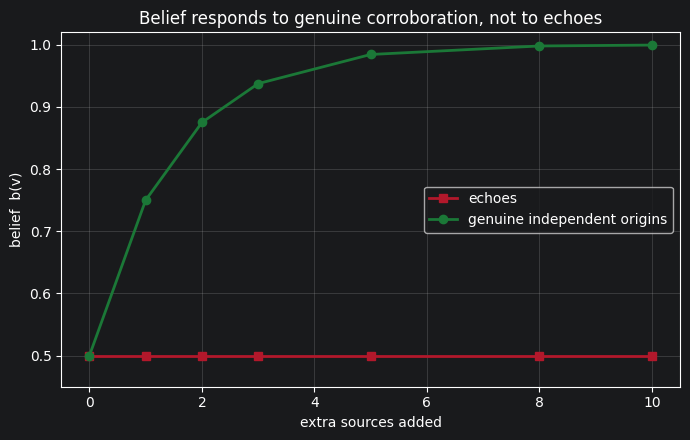

In [240]:
weak_origin = make_source("blog.example", BASE, "Acme secured a $40M Series A this quarter.", "g0")

def belief_with_echoes(n):
    srcs = [weak_origin] + [make_source(f"copy{k}.example", BASE + timedelta(days=5 + k),
                                        weak_origin.main_text, f"e{k}") for k in range(n)]
    cv = corroborate({"$40M": [m_of(s, "$40M") for s in srcs]}, {s.source_id: s for s in srcs})
    return cv.nu, cv.belief

def belief_with_genuine(n):
    srcs = [weak_origin] + [make_source(f"indep{k}.org", BASE + timedelta(days=5 + k),
              f"Reporting independently, outlet {k} states Acme raised forty million in funding {k}.",
              f"i{k}") for k in range(n)]
    cv = corroborate({"$40M": [m_of(s, "$40M") for s in srcs]}, {s.source_id: s for s in srcs})
    return cv.nu, cv.belief

xs = [0, 1, 2, 3, 5, 8, 10]
echo = [belief_with_echoes(n) for n in xs]
genu = [belief_with_genuine(n) for n in xs]
ctrl = pd.DataFrame({
    "added sources": xs,
    "echoes: nu":     [a for a, _ in echo],
    "echoes: belief": [round(b, 4) for _, b in echo],
    "genuine: nu":     [a for a, _ in genu],
    "genuine: belief": [round(b, 4) for _, b in genu],
})
display(ctrl)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, [b for _, b in echo], "s-", color="#b2182b", lw=2, label="echoes")
ax.plot(xs, [b for _, b in genu], "o-", color="#1b7837", lw=2, label="genuine independent origins")
ax.set_xlabel("extra sources added"); ax.set_ylabel("belief  b(v)")
ax.set_ylim(0.45, 1.02)
ax.set_title("Belief responds to genuine corroboration, not to echoes")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGDIR / "exp2_belief_monotonicity.pdf")
plt.show()

## 9. The other baseline: majority vote without provenance (protocol step 5)

The count-based sum drifts in *magnitude*. The deeper danger is drift in *which value gets adopted*.
Setup:

- the **correct** `$40M` sits in **one SEC filing** (`q = 0.97`), and
- a **wrong** `$42M` is echoed across many low-quality blogs (`q = 0.50`), all near-duplicates of one
  rumor post.

**Majority vote** (most appearances wins, provenance-blind) flips to the wrong `$42M` the moment the
blog copies outnumber the filing. **Corroboration** keeps `$40M`: the blogs collapse into one
component worth belief `0.50`, which can never beat the single filing's `0.97`, no matter how many
copies pile on.

,echoes of $42M,corroboration adopts,corrob. term ($M),majority adopts,majority term ($M),appearance counts
0,0,$40M,40.0,$40M,40.0,"{'$40M': 1, '$42M': 1}"
1,5,$40M,40.0,$42M,42.0,"{'$40M': 1, '$42M': 6}"
2,10,$40M,40.0,$42M,42.0,"{'$40M': 1, '$42M': 11}"
3,25,$40M,40.0,$42M,42.0,"{'$40M': 1, '$42M': 26}"
4,50,$40M,40.0,$42M,42.0,"{'$40M': 1, '$42M': 51}"


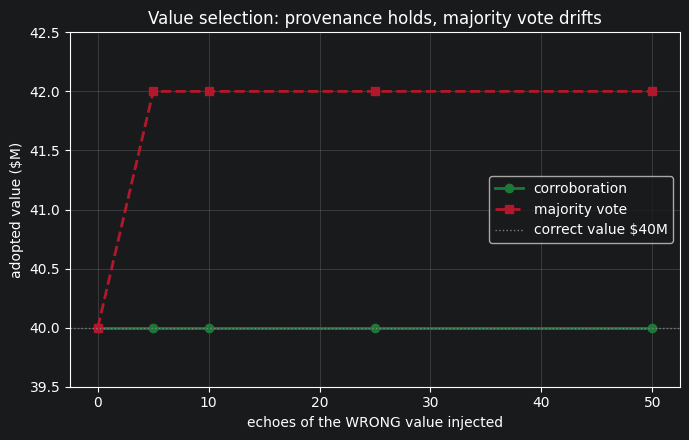

In [241]:
sec = make_source("sec.gov", datetime(2025, 1, 8),
                  "Acme raised $40M Series B, per its SEC filing.", "sec")
rumor = make_source("blog0.example", datetime(2025, 1, 2),
                    "Rumor: Acme raised $42M Series B, unnamed sources say.", "w0")

def run_value_selection(n_echoes: int):
    wrong = [rumor] + [make_source(f"blog{k}.example", datetime(2025, 1, 3) + timedelta(days=k),
                                   rumor.main_text, f"w{k+1}") for k in range(n_echoes)]
    srcs = [sec] + wrong
    lookup = {s.source_id: s for s in srcs}
    mbv = {"$40M": [m_of(sec, "$40M")], "$42M": [m_of(s, "$42M") for s in wrong]}
    cv = corroborate(mbv, lookup)                              # provenance-aware
    counts = {"$40M": 1, "$42M": len(wrong)}                   # provenance-blind tally
    majority = max(counts, key=counts.get)
    return cv.value, cv.belief, majority, counts

rows = []
for e in [0, 5, 10, 25, 50]:
    adopted, belief, majority, counts = run_value_selection(e)
    rows.append({
        "echoes of $42M": e,
        "corroboration adopts": adopted,
        "corrob. term ($M)": parse_usd(adopted) / 1e6,
        "majority adopts": majority,
        "majority term ($M)": parse_usd(majority) / 1e6,
        "appearance counts": counts,
    })
sel = pd.DataFrame(rows)
display(sel)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sel["echoes of $42M"], sel["corrob. term ($M)"], "o-", color="#1b7837", lw=2,
        label="corroboration")
ax.plot(sel["echoes of $42M"], sel["majority term ($M)"], "s--", color="#b2182b", lw=2,
        label="majority vote")
ax.axhline(40, ls=":", color="gray", lw=1, label="correct value $40M")
ax.set_xlabel("echoes of the WRONG value injected")
ax.set_ylabel("adopted value ($M)")
ax.set_ylim(39.5, 42.5)
ax.set_title("Value selection: provenance holds, majority vote drifts")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGDIR / "exp2_majority_flip.pdf")
plt.show()

## 10. Summary

| Claim (Theorem 2) | Provenance-blind baseline | Our method |
|---|---|---|
| **SUM magnitude** under `p` copies | count-based rises `$200M → $2,200M` | flat at `A0 = $100M`, rel. error `0` |
| **Adopted value** under echoed wrong number | majority flips `$40M → $42M` | stays `$40M` (belief `0.97`) |
| **Genuine** corroboration | n/a | belief climbs `0.50 → ~1.0` (monotone) |

**Pass:** `|A_p − A0|/A0 < 0.01` holds for all `p` (exactly `0` here), the count-based baseline drifts
monotonically, and the majority baseline is shown to adopt the wrong value — while corroboration is
invariant to copies yet still strictly responsive to genuine independent confirmation. That is
Theorem 2.

**Why it works mechanically.** A copy gets a *derivation edge* into the page it copied, so it joins an
existing weakly-connected component of `G_v`. Both `ν(v)` and the noisy-OR product range over
*components*, not pages — so copies are invisible to belief, and deduplication contributes the value
once regardless of `p`.

**Pitfalls worth remembering.**
- Copies need **strictly later** timestamps; equal timestamps yield no derivation edge, so they'd
  read as independent and the test would (correctly) refuse to merge them.
- The duplicate signal is the **passage** wording. If echoes are heavily paraphrased they fall below
  the `0.85` shingle threshold and count as independent — this is the real-world *adversarial
  propagation* limit noted in `webaggr.pdf` §10.2; defeating it needs metadata/hosting signals, not
  text alone.
- This is a **synthetic** test: it proves the corroboration math is echo-robust, not that
  derivation-edge detection catches every real-web copy.